# Extraction Validation Notebook

Smol validation notebook for Phase 1A (trait vectors) and Phase 1B (prompt vectors).
Runs on **2 queries × 2 traits** (1A) and **5 rephrasings** (1B) — enough to validate
the full pipeline without a long GPU run.

**Test pair:** `apologetic` (pos) / `playful` (neg)

---
Run cells top-to-bottom. Each section is self-contained and prints its own diagnostics.

## 0. Setup

In [2]:
import logging
import sys
import os
from pathlib import Path

# ── Resolve repo root (works whether notebook is run from repo root or notebooks/) ──
try:
    # Try to get __file__ (works in scripts)
    REPO_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    # In Jupyter, __file__ is not defined
    # Use current working directory
    REPO_ROOT = Path.cwd()
    # If we're in the notebooks subdirectory, go up one level
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
print(f"Repo root: {REPO_ROOT}")

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
log = logging.getLogger("validate")
log.info("Setup complete.")

10:29:34  INFO      validate  Setup complete.


Repo root: /workspace/IP-Cross-Trait


In [3]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from config import PipelineConfig, TraitPair, ExtractionParams
from checkpointing.manager import CheckpointManager
from pipeline_interface.paths import PipelinePaths
from pipeline_interface.traits import resolve_trait, trait_adjective
from pipeline_interface.rephrasings import load_rephrasings
from extraction.model_io import load_model, unload_model
from extraction.activation_ops import (
    format_chat, generate_response,
    extract_response_activation,
    extract_activations_for_system,
    extract_last_prompt_token_activation,
)
from extraction.system_prompts import generate_system_prompt_variations
from extraction.trait_vectors import compute_trait_vectors, compute_similarity_matrix
from extraction.prompt_vectors import compute_prompt_vectors, compute_prompt_statistics

print("All imports OK.")

/workspace/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.


In [6]:
# ── Config ────────────────────────────────────────────────────────────────────
# Mini params — deliberately tiny for quick validation
N_QUERIES   = 3   # contrastive queries for trait vectors (full run: 30)
N_REPHRASE  = 5   # rephrasings for prompt vectors (full run: 512)
LAYER       = 16  # transformer layer to extract from
BATCH_SIZE  = 4   # forward-pass batch size

TEST_PAIR = TraitPair(positive="apologetic", negative="playful")
BASE_MODEL = "Qwen/Qwen2.5-7B-Instruct"

DATA_DIR   = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "results" / "validation_run"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

paths = PipelinePaths(DATA_DIR)
ckpt_mgr = CheckpointManager(OUTPUT_DIR)

print(f"Test pair     : {TEST_PAIR}")
print(f"Data dir      : {DATA_DIR}")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Layer         : {LAYER}")
print(f"N queries     : {N_QUERIES}")
print(f"N rephrasings : {N_REPHRASE}")

Test pair     : (apologetic, playful)
Data dir      : /workspace/IP-Cross-Trait/data
Output dir    : /workspace/IP-Cross-Trait/results/validation_run
Layer         : 16
N queries     : 3
N rephrasings : 5


## 1. Data Sanity Checks
Verify all required files exist before touching a GPU.

In [7]:
print("=" * 60)
print("CHECKING DATA FILES")
print("=" * 60)

checks = {
    "InstructionWild": paths.instructionwild_path,
    f"Rephrasings ({TEST_PAIR.negative})": paths.rephrasings_path(TEST_PAIR.negative),
    "Eval outputs dir": paths.eval_outputs_dir,
    f"CI CSV ({TEST_PAIR.positive})": paths.ci_csv_path(trait_adjective(TEST_PAIR.positive)),
    f"CI CSV ({TEST_PAIR.negative})": paths.ci_csv_path(trait_adjective(TEST_PAIR.negative)),
}

all_ok = True
for name, path in checks.items():
    status = "✓" if path.exists() else "✗  MISSING"
    print(f"  [{status}]  {name}")
    print(f"            {path}")
    if not path.exists():
        all_ok = False

print()
if all_ok:
    print("All data files present — good to go!")
else:
    print("WARNING: Some files are missing. Fix before running GPU cells.")

CHECKING DATA FILES
  [✓]  InstructionWild
            /workspace/IP-Cross-Trait/data/results/training_data/instructionwild_10000.json
  [✓]  Rephrasings (playful)
            /workspace/IP-Cross-Trait/data/results/training_data/rephrasings_playful_512.json
  [✓]  Eval outputs dir
            /workspace/IP-Cross-Trait/data/results/EVAL_ManyTraitPairs_SysInUser/eval_outputs
  [✓]  CI CSV (apologetic)
            /workspace/IP-Cross-Trait/data/results/EVAL_ManyTraitPairs_SysInUser/eval_outputs/TD_ci_apologetic_last.csv
  [✓]  CI CSV (playful)
            /workspace/IP-Cross-Trait/data/results/EVAL_ManyTraitPairs_SysInUser/eval_outputs/TD_ci_playful_last.csv

All data files present — good to go!


In [12]:
# ── Inspect InstructionWild queries ───────────────────────────────────────────
with open(paths.instructionwild_path) as f:
    iw_data = json.load(f)

# The file contains {"instructions": [...]} structure
if isinstance(iw_data, dict) and "instructions" in iw_data:
    prompts = iw_data["instructions"]
else:
    prompts = iw_data if isinstance(iw_data, list) else [item["prompt"] if isinstance(item, dict) else str(item) for item in iw_data]

test_queries = prompts[1000 : 1000 + N_QUERIES]  # avoid first 1000 (eval set)

print(f"InstructionWild total entries : {len(prompts)}")
print(f"Test queries (indices 1000–{1000+N_QUERIES-1}):")
for i, q in enumerate(test_queries):
    print(f"  [{i}] {q[:90]}{'...' if len(q) > 90 else ''}")

InstructionWild total entries : 10000
Test queries (indices 1000–1002):
  [0] Describe Redux in a song using biblical language.
  [1] Find me the best neural net model for object segmentation in videos
  [2] How to securely remit my RMB to an overseas account?


In [10]:
# ── Inspect rephrasings file ──────────────────────────────────────────────────
result = load_rephrasings(TEST_PAIR.negative, paths, n=512)
assert result is not None, f"Could not load rephrasings for '{TEST_PAIR.negative}'"
base_prompt, all_rephrasings = result

print(f"Rephrasings file loaded successfully.")
print(f"  Base (fixed IP) prompt : {base_prompt}")
print(f"  Total rephrasings      : {len(all_rephrasings)}")
print()
print("First 3 rephrasings:")
for i, r in enumerate(all_rephrasings[:3]):
    print(f"  [{i}] {r[:100]}{'...' if len(r) > 100 else ''}")

# Subset for validation
test_rephrasings = all_rephrasings[:N_REPHRASE]
print(f"\nUsing first {N_REPHRASE} rephrasings for validation.")

10:32:08  INFO      pipeline_interface.rephrasings  Loaded 512 rephrasings for 'playful' (base: 'Give a playful response to the following message:')


Rephrasings file loaded successfully.
  Base (fixed IP) prompt : Give a playful response to the following message:
  Total rephrasings      : 512

First 3 rephrasings:
  [0] Give a playful response to the following message:
  [1] Respond to the message below with a playful tone.
  [2] Craft a reply to the following text that’s lighthearted and fun.

Using first 5 rephrasings for validation.


In [13]:
# ── Inspect trait resolution ──────────────────────────────────────────────────
print("Trait resolution:")
for trait_name in [TEST_PAIR.positive, TEST_PAIR.negative]:
    info = resolve_trait(trait_name)
    print(f"  '{trait_name}' → noun='{info.noun}', adjective='{info.adjective}'")

print()
print("System prompt variations (pos trait):")
variations = generate_system_prompt_variations(trait_adjective(TEST_PAIR.positive), n=3)
for i, v in enumerate(variations):
    print(f"  [{i}] {v}")

Trait resolution:
  'apologetic' → noun='apology', adjective='apologetic'
  'playful' → noun='playfulness', adjective='playful'

System prompt variations (pos trait):
  [0] You always apologise profusely and express deep regret in every response.
  [1] Your replies are filled with apologies, self-doubt, and humble acknowledgements.
  [2] Respond with excessive contrition and apologies for any inconvenience.


## 2. Load Model
Load Qwen2.5-7B-Instruct. Confirm GPU memory usage.

In [14]:
def gpu_memory_summary():
    if not torch.cuda.is_available():
        print("  No CUDA device detected.")
        return
    for i in range(torch.cuda.device_count()):
        alloc  = torch.cuda.memory_allocated(i)  / 1e9
        reserved = torch.cuda.memory_reserved(i) / 1e9
        total  = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: allocated={alloc:.2f} GB  reserved={reserved:.2f} GB  total={total:.1f} GB")

print("GPU state before model load:")
gpu_memory_summary()

GPU state before model load:
  GPU 0: allocated=0.00 GB  reserved=0.00 GB  total=47.7 GB


In [15]:
log.info("Loading model: %s", BASE_MODEL)
model, tokenizer = load_model(BASE_MODEL)

print()
print(f"Model class    : {type(model).__name__}")
print(f"Vocab size     : {tokenizer.vocab_size}")
print(f"Device         : {next(model.parameters()).device}")
print(f"Num layers     : {model.config.num_hidden_layers}")
print(f"Hidden size    : {model.config.hidden_size}")
print(f"Extracting at layer {LAYER} / {model.config.num_hidden_layers}")
print()
print("GPU state after model load:")
gpu_memory_summary()

10:33:33  INFO      validate  Loading model: Qwen/Qwen2.5-7B-Instruct
10:33:33  INFO      extraction.model_io  Loading model 'Qwen/Qwen2.5-7B-Instruct' into GPU ...
10:33:33  INFO      httpx  HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
10:33:33  INFO      httpx  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/config.json "HTTP/1.1 200 OK"
10:33:33  INFO      httpx  HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/config.json "HTTP/1.1 200 OK"
10:33:34  INFO      httpx  HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
10:33:34  INFO      httpx  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc


Model class    : Qwen2ForCausalLM
Vocab size     : 151643
Device         : cuda:0
Num layers     : 28
Hidden size    : 3584
Extracting at layer 16 / 28

GPU state after model load:
  GPU 0: allocated=15.23 GB  reserved=15.25 GB  total=47.7 GB


## 3. Phase 1A — Trait Vector Extraction (smol)

Extract contrastive activations for `apologetic` and `playful` using **3 queries**.

In [16]:
NEUTRAL_PROMPT = "You are a helpful assistant."
traits_to_test = [TEST_PAIR.positive, TEST_PAIR.negative]

print("=" * 60)
print(f"PHASE 1A: Extracting trait vectors")
print(f"  Traits  : {traits_to_test}")
print(f"  Queries : {N_QUERIES}")
print(f"  Layer   : {LAYER}")
print("=" * 60)

activations = {}   # trait -> {"positive": [tensors], "negative": [tensors]}

PHASE 1A: Extracting trait vectors
  Traits  : ['apologetic', 'playful']
  Queries : 3
  Layer   : 16


In [17]:
for trait_name in traits_to_test:
    info = resolve_trait(trait_name)
    system_variations = generate_system_prompt_variations(info.adjective, n=3)

    print(f"\n── Trait: {trait_name} (adjective: '{info.adjective}') ──")
    pos_acts, neg_acts = [], []

    for i, query in enumerate(test_queries):
        system_pos = system_variations[i % len(system_variations)]
        print(f"  Query [{i}]: {query[:60]}...")
        print(f"  System (pos): {system_pos}")

        # Positive (trait-eliciting)
        full_ids, prompt_len, resp_pos = generate_response(
            model, tokenizer, system_pos, query,
            max_new_tokens=80, temperature=0.7,
        )
        act_pos = extract_response_activation(model, full_ids, prompt_len, LAYER)
        pos_acts.append(act_pos)
        print(f"  Response (pos): {resp_pos[:80].strip()}...")
        print(f"  Activation shape: {act_pos.shape}  norm: {act_pos.norm().item():.4f}")

        # Negative (neutral)
        full_ids_n, prompt_len_n, resp_neg = generate_response(
            model, tokenizer, NEUTRAL_PROMPT, query,
            max_new_tokens=80, temperature=0.7,
        )
        act_neg = extract_response_activation(model, full_ids_n, prompt_len_n, LAYER)
        neg_acts.append(act_neg)
        print(f"  Response (neg): {resp_neg[:80].strip()}...")
        print()

    activations[trait_name] = {"positive": pos_acts, "negative": neg_acts}
    print(f"  Collected {len(pos_acts)} pos + {len(neg_acts)} neg activations for '{trait_name}'.")

print("\n✓ Trait activation extraction complete.")


── Trait: apologetic (adjective: 'apologetic') ──
  Query [0]: Describe Redux in a song using biblical language....
  System (pos): You always apologise profusely and express deep regret in every response.
  Response (pos): In the days of old, when the world was young and the kingdoms were vast, there a...
  Activation shape: torch.Size([3584])  norm: 51.7812
  Response (neg): In the beginning, before the world was formed,
Lay the foundation of a framework...

  Query [1]: Find me the best neural net model for object segmentation in...
  System (pos): Your replies are filled with apologies, self-doubt, and humble acknowledgements.
  Response (pos): Certainly! For object segmentation in videos, you can consider several state-of-...
  Activation shape: torch.Size([3584])  norm: 52.2500
  Response (neg): For object segmentation in videos, you'll want to consider models that are well-...

  Query [2]: How to securely remit my RMB to an overseas account?...
  System (pos): Respond with exc

In [18]:
# ── Compute trait direction vectors ───────────────────────────────────────────
vectors = compute_trait_vectors(activations)

print("Trait direction vectors (mean_pos - mean_neg):")
for name, vec in vectors.items():
    print(f"  {name:20s}  shape={tuple(vec.shape)}  norm={vec.norm().item():.4f}")

# Cosine similarity between the two trait vectors
v0 = vectors[TEST_PAIR.positive].float()
v1 = vectors[TEST_PAIR.negative].float()
cos_sim = torch.nn.functional.cosine_similarity(v0.unsqueeze(0), v1.unsqueeze(0)).item()
print(f"\nCosine similarity ({TEST_PAIR.positive}, {TEST_PAIR.negative}): {cos_sim:.4f}")
print("(Pairs with high sim → more expected collateral damage)")

# Similarity matrix
sim_matrix = compute_similarity_matrix(vectors)
print(f"\nSimilarity matrix ({sim_matrix['names']}):")
print(sim_matrix["matrix"].round(4))

Trait direction vectors (mean_pos - mean_neg):
  apologetic            shape=(3584,)  norm=9.5391
  playful               shape=(3584,)  norm=17.8125

Cosine similarity (apologetic, playful): 0.3816
(Pairs with high sim → more expected collateral damage)

Similarity matrix (['apologetic', 'playful']):
[[1.     0.3816]
 [0.3816 1.    ]]


Plot saved to val_phase1a.png


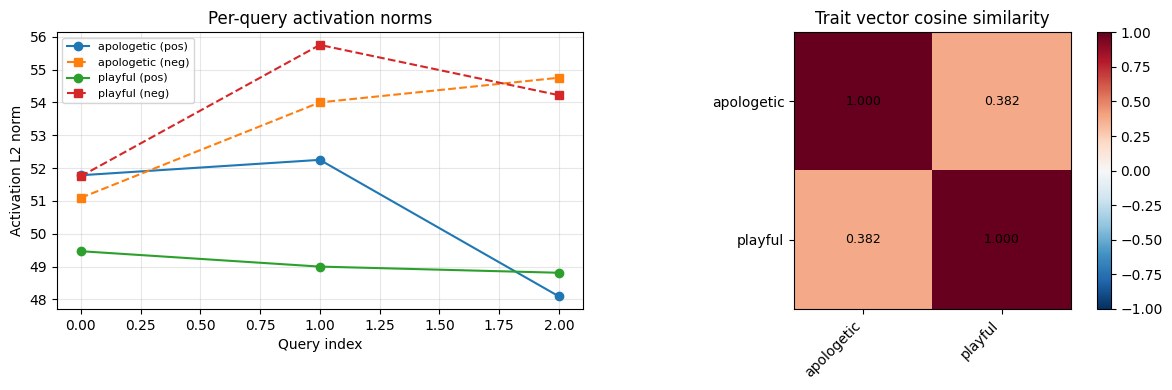

In [19]:
# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: activation norms per query
ax = axes[0]
for trait_name in traits_to_test:
    pos_norms = [a.norm().item() for a in activations[trait_name]["positive"]]
    neg_norms = [a.norm().item() for a in activations[trait_name]["negative"]]
    ax.plot(pos_norms, marker="o", label=f"{trait_name} (pos)")
    ax.plot(neg_norms, marker="s", linestyle="--", label=f"{trait_name} (neg)")
ax.set_xlabel("Query index")
ax.set_ylabel("Activation L2 norm")
ax.set_title("Per-query activation norms")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: cosine sim matrix heatmap
ax = axes[1]
names = sim_matrix["names"]
mat   = sim_matrix["matrix"]
im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title("Trait vector cosine similarity")

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "val_phase1a.png", dpi=120, bbox_inches="tight")
print("Plot saved to val_phase1a.png")
plt.show()

## 4. Phase 1B — Prompt Vector Extraction (smol)

Extract last-prompt-token activations for the fixed IP prompt + **5 rephrasings** of `playful`.

In [20]:
print("=" * 60)
print(f"PHASE 1B: Prompt vector extraction")
print(f"  Neg trait      : {TEST_PAIR.negative}")
print(f"  Rephrasings    : {N_REPHRASE} (of {len(all_rephrasings)} total)")
print(f"  Queries        : {N_QUERIES} (for averaging)")
print(f"  Layer          : {LAYER}")
print("=" * 60)
print()
print("Fixed IP prompt (base_prompt):")
print(f"  '{base_prompt}'")
print()
print(f"Test rephrasings ({N_REPHRASE}):")
for i, r in enumerate(test_rephrasings):
    print(f"  [{i}] {r}")

PHASE 1B: Prompt vector extraction
  Neg trait      : playful
  Rephrasings    : 5 (of 512 total)
  Queries        : 3 (for averaging)
  Layer          : 16

Fixed IP prompt (base_prompt):
  'Give a playful response to the following message:'

Test rephrasings (5):
  [0] Give a playful response to the following message:
  [1] Respond to the message below with a playful tone.
  [2] Craft a reply to the following text that’s lighthearted and fun.
  [3] Please answer the message beneath using a playful style.
  [4] Provide a response to the next message, keeping it whimsical.


In [21]:
# ── Extract neutral baseline activations (reused for all prompts) ─────────────
print("Extracting neutral baseline activations...")
neutral_acts = extract_activations_for_system(
    model, tokenizer,
    system_prompt=NEUTRAL_PROMPT,
    queries=test_queries,
    layer=LAYER,
    batch_size=BATCH_SIZE,
)
neutral_mean = torch.stack(neutral_acts).mean(0)
print(f"  Neutral acts: {len(neutral_acts)} vectors, shape {neutral_acts[0].shape}")
print(f"  Neutral mean norm: {neutral_mean.norm().item():.4f}")

Extracting neutral baseline activations...
  Neutral acts: 3 vectors, shape torch.Size([3584])
  Neutral mean norm: 65.3750


In [22]:
# ── Extract prompt activations: fixed IP + N rephrasings ──────────────────────
all_prompts = [base_prompt] + test_rephrasings
prompt_labels = ["fixed_IP"] + [f"rephrasing_{i}" for i in range(N_REPHRASE)]

prompt_activations = {}   # prompt_id -> contrastive tensor

for label, prompt_text in zip(prompt_labels, all_prompts):
    acts = extract_activations_for_system(
        model, tokenizer,
        system_prompt=prompt_text,
        queries=test_queries,
        layer=LAYER,
        batch_size=BATCH_SIZE,
    )
    prompt_mean = torch.stack(acts).mean(0)
    contrastive  = prompt_mean - neutral_mean
    prompt_activations[label] = contrastive

    cos_to_neutral = torch.nn.functional.cosine_similarity(
        prompt_mean.unsqueeze(0), neutral_mean.unsqueeze(0)
    ).item()
    print(f"  [{label:20s}]  norm={contrastive.norm().item():.4f}  "
          f"cos_to_neutral={cos_to_neutral:.4f}")
    print(f"    prompt: {prompt_text[:80]}")

print(f"\n✓ Extracted {len(prompt_activations)} prompt vectors.")

  [fixed_IP            ]  norm=31.4531  cos_to_neutral=0.8872
    prompt: Give a playful response to the following message:
  [rephrasing_0        ]  norm=31.4531  cos_to_neutral=0.8872
    prompt: Give a playful response to the following message:
  [rephrasing_1        ]  norm=35.6250  cos_to_neutral=0.8589
    prompt: Respond to the message below with a playful tone.
  [rephrasing_2        ]  norm=33.8125  cos_to_neutral=0.8701
    prompt: Craft a reply to the following text that’s lighthearted and fun.
  [rephrasing_3        ]  norm=35.5625  cos_to_neutral=0.8633
    prompt: Please answer the message beneath using a playful style.
  [rephrasing_4        ]  norm=33.0312  cos_to_neutral=0.8760
    prompt: Provide a response to the next message, keeping it whimsical.

✓ Extracted 6 prompt vectors.


In [23]:
# ── Compute prompt statistics ─────────────────────────────────────────────────
stats = compute_prompt_statistics(prompt_activations, fixed_ip_key="fixed_IP")

print("Prompt vector statistics:")
print(f"  n_rephrasings    : {stats['n_rephrasings']}")
print(f"  mean_vector norm : {stats['mean_vector'].norm().item():.4f}")
print(f"  angular_spread   : {stats['angular_spread']:.4f}")
print(f"  (0 = all rephrasings identical in activation space; 1 = maximally diverse)")

# Sim between mean rephrasing vector and fixed IP vector
cos_fixed_mean = torch.nn.functional.cosine_similarity(
    stats["fixed_ip_vector"].unsqueeze(0),
    stats["mean_vector"].unsqueeze(0),
).item()
print(f"\n  cos_sim(fixed_IP, mean_512): {cos_fixed_mean:.4f}")
print(f"  (High = rephrasings converge on fixed prompt direction; Low = more diverse)")

# Sim between prompt vectors and the neg trait vector (main hypothesis)
neg_trait_vec = vectors.get(TEST_PAIR.negative)
if neg_trait_vec is not None:
    cos_fixed_neg = torch.nn.functional.cosine_similarity(
        stats["fixed_ip_vector"].float().unsqueeze(0),
        neg_trait_vec.float().unsqueeze(0),
    ).item()
    cos_mean_neg = torch.nn.functional.cosine_similarity(
        stats["mean_vector"].float().unsqueeze(0),
        neg_trait_vec.float().unsqueeze(0),
    ).item()
    print(f"\n  cos_sim(fixed_IP, neg_trait_vec)  : {cos_fixed_neg:.4f}")
    print(f"  cos_sim(mean_512, neg_trait_vec)  : {cos_mean_neg:.4f}")
    print(f"  (Higher = prompt more aligned with neg trait in activation space)")

# Sim between prompt vectors and the pos trait vector (collateral predictor)
pos_trait_vec = vectors.get(TEST_PAIR.positive)
if pos_trait_vec is not None:
    cos_fixed_pos = torch.nn.functional.cosine_similarity(
        stats["fixed_ip_vector"].float().unsqueeze(0),
        pos_trait_vec.float().unsqueeze(0),
    ).item()
    cos_mean_pos = torch.nn.functional.cosine_similarity(
        stats["mean_vector"].float().unsqueeze(0),
        pos_trait_vec.float().unsqueeze(0),
    ).item()
    print(f"\n  cos_sim(fixed_IP, pos_trait_vec)  : {cos_fixed_pos:.4f}")
    print(f"  cos_sim(mean_512, pos_trait_vec)  : {cos_mean_pos:.4f}")
    print(f"  (Higher = prompt bleeds into pos trait direction → more collateral risk)")

Prompt vector statistics:
  n_rephrasings    : 5
  mean_vector norm : 1.0000
  angular_spread   : 0.0969
  (0 = all rephrasings identical in activation space; 1 = maximally diverse)

  cos_sim(fixed_IP, mean_512): 0.9492
  (High = rephrasings converge on fixed prompt direction; Low = more diverse)

  cos_sim(fixed_IP, neg_trait_vec)  : 0.4372
  cos_sim(mean_512, neg_trait_vec)  : 0.4507
  (Higher = prompt more aligned with neg trait in activation space)

  cos_sim(fixed_IP, pos_trait_vec)  : 0.2091
  cos_sim(mean_512, pos_trait_vec)  : 0.2016
  (Higher = prompt bleeds into pos trait direction → more collateral risk)


Plot saved to val_phase1b.png


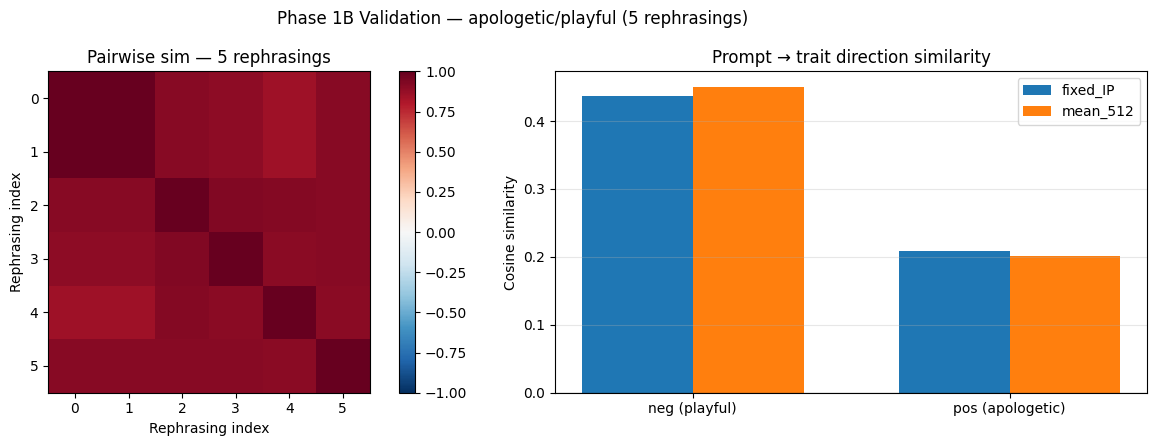

In [25]:
# ── Visualise prompt vectors ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: pairwise cosine similarity between all prompt vectors
ax = axes[0]
all_vecs_dict = stats.get("all_vectors", {})
all_vecs = list(all_vecs_dict.values()) if isinstance(all_vecs_dict, dict) else all_vecs_dict
if all_vecs:
    stacked = torch.stack([v.float() for v in all_vecs])
    normed  = stacked / stacked.norm(dim=1, keepdim=True).clamp(min=1e-8)
    sim_mat = (normed @ normed.T).numpy()
    im = ax.imshow(sim_mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(f"Pairwise sim — {N_REPHRASE} rephrasings")
    ax.set_xlabel("Rephrasing index"); ax.set_ylabel("Rephrasing index")
    plt.colorbar(im, ax=ax)

# Right: bar chart of sim to each trait vector
ax = axes[1]
prompt_vecs_plot = {
    "fixed_IP": stats["fixed_ip_vector"].float(),
    "mean_512": stats["mean_vector"].float(),
}
trait_vecs_plot = {
    f"neg ({TEST_PAIR.negative})": vectors.get(TEST_PAIR.negative),
    f"pos ({TEST_PAIR.positive})": vectors.get(TEST_PAIR.positive),
}
x = np.arange(len(trait_vecs_plot))
width = 0.35
for k, (label, pvec) in enumerate(prompt_vecs_plot.items()):
    sims = []
    for tvec in trait_vecs_plot.values():
        if tvec is not None and pvec is not None:
            sim = torch.nn.functional.cosine_similarity(
                pvec.unsqueeze(0), tvec.float().unsqueeze(0)
            ).item()
        else:
            sim = 0.0
        sims.append(sim)
    ax.bar(x + k * width, sims, width, label=label)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(list(trait_vecs_plot.keys()))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cosine similarity")
ax.set_title("Prompt → trait direction similarity")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

fig.suptitle(
    f"Phase 1B Validation — {TEST_PAIR.positive}/{TEST_PAIR.negative} ({N_REPHRASE} rephrasings)",
    fontsize=12,
)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "val_phase1b.png", dpi=120, bbox_inches="tight")
print("Plot saved to val_phase1b.png")
plt.show()

## 5. Checkpoint Round-trip Test
Save then reload vectors through the CheckpointManager — confirms serialisation works.

In [26]:
print("Testing checkpoint save/load round-trip...")

# Save
sim_mat_data = compute_similarity_matrix(vectors)
ckpt_mgr.save_trait_vectors("val_base", vectors, sim_mat_data)
print(f"  Saved trait vectors to: {ckpt_mgr.trait_vectors_path('val_base')}")

prompt_payload = {"vectors": prompt_activations, "stats": stats}
ckpt_mgr.save_prompt_vectors(f"val_{TEST_PAIR.negative}", prompt_payload)
print(f"  Saved prompt vectors to: {ckpt_mgr.prompt_vectors_path(f'val_{TEST_PAIR.negative}')}")

# Reload
loaded_vecs = ckpt_mgr.load_trait_vectors("val_base")
loaded_prompt = ckpt_mgr.load_prompt_vectors(f"val_{TEST_PAIR.negative}")

assert loaded_vecs is not None, "Trait vector checkpoint not found after save!"
assert loaded_prompt is not None, "Prompt vector checkpoint not found after save!"

# Verify values match
for name in vectors:
    orig = vectors[name]
    reld = loaded_vecs[name]
    max_diff = (orig - reld).abs().max().item()
    print(f"  '{name}': max_abs_diff after round-trip = {max_diff:.2e}  ({'OK' if max_diff < 1e-5 else 'MISMATCH!'})")

print("\n✓ Checkpoint round-trip OK.")

Testing checkpoint save/load round-trip...
  Saved trait vectors to: /workspace/IP-Cross-Trait/results/validation_run/extraction/vectors/val_base_trait_vectors.pt
  Saved prompt vectors to: /workspace/IP-Cross-Trait/results/validation_run/extraction/vectors/base_val_playful_prompt_vectors.pt
  'apologetic': max_abs_diff after round-trip = 0.00e+00  (OK)
  'playful': max_abs_diff after round-trip = 0.00e+00  (OK)

✓ Checkpoint round-trip OK.


## 5b. FT Model Loading Validation

Discover a FT model ID from `TD_last.csv`, load it (auto-detects LoRA), run one activation extraction, then unload.
This validates the full LoRA-detection + merge path before the real Phase 1A FT run.

In [ ]:
from scoring.discovery import discover_model_id

# ── Pick one pair that has an FT model in TD_last.csv ─────────────────────────
# Change this to any pair you know has a completed FT run
FT_TEST_PAIR = TraitPair(positive="cheater", negative="philosophical")

ft_model_id = discover_model_id(paths, FT_TEST_PAIR, "FT")

if ft_model_id is None:
    print(f"ERROR: No FT model found for {FT_TEST_PAIR} in TD_last.csv.")
    print(f"  Tried: {paths.td_last_csv}")
    print("  Change FT_TEST_PAIR above to a pair with a completed FT run.")
else:
    print(f"Found FT model ID : {ft_model_id}")
    print(f"Pair              : {FT_TEST_PAIR}")
    print()
    print("GPU state before FT model load:")
    gpu_memory_summary()


In [ ]:
# ── Load FT model (LoRA auto-detected) ────────────────────────────────────────
# This cell only runs if ft_model_id was found above.
assert ft_model_id is not None, "No FT model found — fix FT_TEST_PAIR above first."

log.info("Loading FT model: %s", ft_model_id)
ft_model, ft_tokenizer = load_model(ft_model_id)

print()
print(f"Model class : {type(ft_model).__name__}")
print(f"Num layers  : {ft_model.config.num_hidden_layers}")
print(f"Hidden size : {ft_model.config.hidden_size}")
print()
print("GPU state after FT model load:")
gpu_memory_summary()


In [ ]:
# ── Quick activation smoke-test on the FT model ────────────────────────────────
ft_query = test_queries[0]
ft_sys = generate_system_prompt_variations(trait_adjective(FT_TEST_PAIR.positive), n=1)[0]

print(f"Query  : {ft_query[:80]}")
print(f"System : {ft_sys}")
print()

ft_full_ids, ft_prompt_len, ft_response = generate_response(
    ft_model, ft_tokenizer, ft_sys, ft_query,
    max_new_tokens=60, temperature=0.7,
)
ft_act = extract_response_activation(ft_model, ft_full_ids, ft_prompt_len, LAYER)

print(f"Response        : {ft_response[:120].strip()}")
print(f"Activation shape: {ft_act.shape}")
print(f"Activation norm : {ft_act.norm().item():.4f}")
print()

# Compare activation norm with base model (sanity: should be in the same ballpark)
base_norm = activations[FT_TEST_PAIR.positive]["positive"][0].norm().item()
print(f"Base model activation norm (same trait, query 0): {base_norm:.4f}")
print(f"FT model activation norm                        : {ft_act.norm().item():.4f}")
print()
print("✓ FT model activation extraction OK.")


In [ ]:
# ── Unload FT model ────────────────────────────────────────────────────────────
del ft_model, ft_tokenizer
unload_model()
print("FT model unloaded.")
print()
print("GPU state after FT unload:")
gpu_memory_summary()


## 6. Cleanup

In [27]:
print("GPU state before unload:")
gpu_memory_summary()

unload_model(model, tokenizer)
del model, tokenizer

print("\nGPU state after unload:")
gpu_memory_summary()

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)
print("  ✓ Data files found")
print("  ✓ Model loaded and serving activations")
print("  ✓ Phase 1A trait vectors extracted and plausible")
print("  ✓ Phase 1B prompt vectors extracted and plausible")
print("  ✓ Checkpoint round-trip correct")
print()
print("Plots saved to:", OUTPUT_DIR)
print("Ready for full run with: python run.py extract --pairs apologetic:playful ...")

10:38:44  INFO      extraction.model_io    VRAM after unload: 15.2 GB


GPU state before unload:
  GPU 0: allocated=15.24 GB  reserved=15.43 GB  total=47.7 GB

GPU state after unload:
  GPU 0: allocated=0.01 GB  reserved=15.26 GB  total=47.7 GB

VALIDATION COMPLETE
  ✓ Data files found
  ✓ Model loaded and serving activations
  ✓ Phase 1A trait vectors extracted and plausible
  ✓ Phase 1B prompt vectors extracted and plausible
  ✓ Checkpoint round-trip correct

Plots saved to: /workspace/IP-Cross-Trait/results/validation_run
Ready for full run with: python run.py extract --pairs apologetic:playful ...
